# Vendor Performance Analysis and Predictive Models

Analyzing vendor efficiency and profitability to support strategic purchasing and inventory decisions, plus two machine-learning models:

1. **Freight cost prediction**: what freight should an invoice carry?
2. **Manual-approval prediction**: which invoices show misbehaviour and need manual approval?

> **Limitation:** no sales file or PO line items exist in the data. Units sold, revenue and gross profit are **estimated** per vendor from the inventory balance equation (begin inventory + purchased units - end inventory) and inventory-weighted shelf prices.

In [1]:
import sys, sqlite3, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import config as cfg

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60, "display.width", 220, "display.float_format", "{:,.2f}".format)
BLUE, ORANGE, GREEN, RED, GREY = "#1f5fae", "#ef6c00", "#2e7d32", "#c62828", "#9e9e9e"

import analysis
from ml_utils import load_artifacts, score_invoices

purchases, summary, sku = analysis.load_tables()
risk = pd.read_csv(cfg.DATA_DIR / cfg.OUT_INVOICE_RISK, parse_dates=["InvoiceDate"])
kf = json.loads((cfg.DATA_DIR / "key_findings.json").read_text())
fm, am = kf["freight_model"], kf["approval_model"]
active = summary[summary["PurchaseOrders"] > 0].sort_values("PurchaseDollars", ascending=False)
SEG = {"Star - expand": GREEN, "Margin builder - tighten stock levels": BLUE, "Volume driver - renegotiate cost": ORANGE,
       "Underperformer - review or exit": RED, "Insufficient data": GREY}
print(f"{kf['purchase_orders_in_period']:,} POs | {kf['active_vendors']} active vendors | ${kf['total_purchases']/1e6:,.1f}M purchases | ${kf['total_freight']/1e6:,.2f}M freight")

5,403 POs | 126 active vendors | $311.6M purchases | $1.59M freight


## Part A - Vendor performance

### A1. Headline KPIs

In [2]:
display(pd.Series({
    "Purchases ($M)": kf["total_purchases"] / 1e6, "Freight ($M)": kf["total_freight"] / 1e6,
    "Units purchased (M)": kf["units_purchased"] / 1e6, "Active vendors": kf["active_vendors"],
    "Top-10 vendor share (%)": kf["top10_share_pct"], "HHI": kf["hhi"],
    "Est. revenue ($M)": kf["est_revenue"] / 1e6, "Est. gross profit ($M)": kf["est_gross_profit"] / 1e6,
    "Est. gross margin (%)": kf["est_gross_margin_pct"],
    "Inventory at cost: begin ($M)": kf["inventory"]["begin_value_at_cost"] / 1e6,
    "Inventory at cost: end ($M)": kf["inventory"]["end_value_at_cost"] / 1e6,
    "Inventory growth (%)": kf["inventory"]["growth_pct"]}, name="value").to_frame())

,value
Purchases ($M),311.61
Freight ($M),1.59
Units purchased (M),32.55
Active vendors,126.00
Top-10 vendor share (%),65.30
HHI,604.24
Est. revenue ($M),498.18
Est. gross profit ($M),150.86
Est. gross margin (%),30.28
Inventory at cost: begin ($M),46.91


### A2. Research question: how concentrated are purchases?

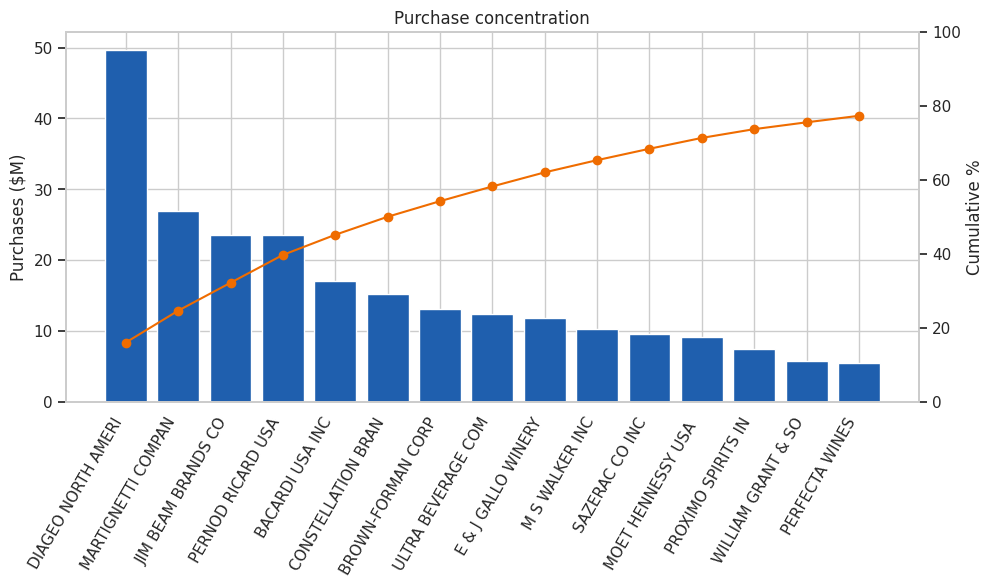

Top 10 vendors = 65.3% of purchases | HHI = 604 | bottom 63 vendors = 0.70% of purchases


In [3]:
top = active.head(15).copy(); top["cum"] = top["PurchaseDollars"].cumsum() / active["PurchaseDollars"].sum() * 100
fig, ax = plt.subplots(figsize=(11, 4.8)); ax.bar(range(15), top["PurchaseDollars"] / 1e6, color=BLUE)
ax.set_xticks(range(15)); ax.set_xticklabels([n[:18] for n in top["VendorName"]], rotation=60, ha="right"); ax.set_ylabel("Purchases ($M)")
ax2 = ax.twinx(); ax2.plot(range(15), top["cum"], color=ORANGE, marker="o"); ax2.set_ylim(0, 100); ax2.grid(False); ax2.set_ylabel("Cumulative %")
plt.title("Purchase concentration"); plt.show()
print(f"Top 10 vendors = {kf['top10_share_pct']:.1f}% of purchases | HHI = {kf['hhi']:.0f} | bottom {kf['bottom_half_vendors']} vendors = {kf['bottom_half_share_pct']:.2f}% of purchases")

The top 10 vendors account for about two thirds of spend: strong negotiating leverage, but also over-reliance risk. The bottom half of vendors (63 of 126) together supply under 1% of spend, a candidate for vendor consolidation.

### A3. Vendor scorecard and segments

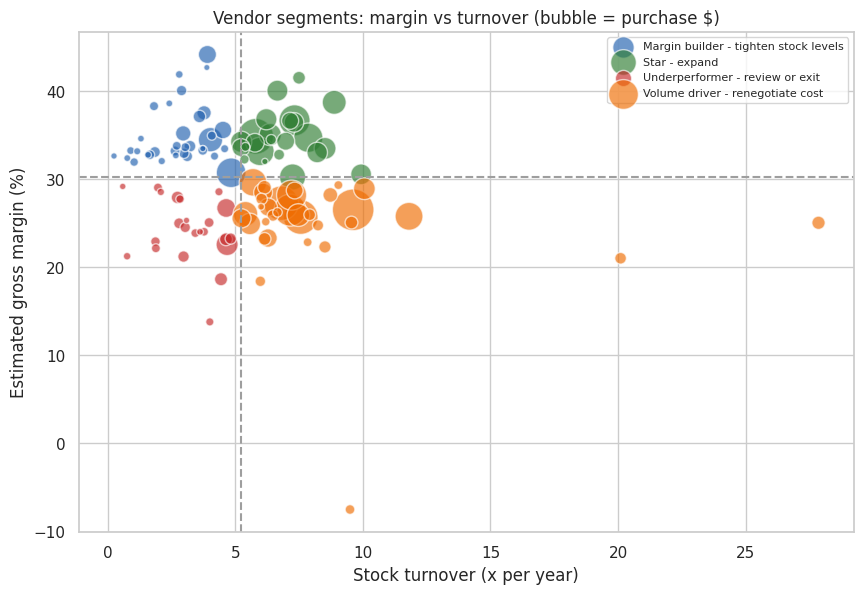

,vendors,share_of_spend_%
Insufficient data,17,0.01
Margin builder - tighten stock levels,34,7.56
Star - expand,24,34.29
Underperformer - review or exit,23,2.38
Volume driver - renegotiate cost,34,55.76


In [4]:
el = summary[summary["ScoreEligible"]]
fig, ax = plt.subplots(figsize=(10, 6.5))
for s, g in el.groupby("Segment"):
    ax.scatter(g["StockTurnover"], g["GrossMarginPct"], s=np.sqrt(g["PurchaseDollars"]) / 8 + 15, alpha=.65, color=SEG[s], label=s, edgecolor="white")
ax.axhline(el["GrossMarginPct"].median(), color=GREY, ls="--"); ax.axvline(el["StockTurnover"].median(), color=GREY, ls="--")
ax.set(xlabel="Stock turnover (x per year)", ylabel="Estimated gross margin (%)", title="Vendor segments: margin vs turnover (bubble = purchase $)"); ax.legend(fontsize=8); plt.show()
seg = pd.DataFrame({"vendors": pd.Series(kf["segment_counts"]), "share_of_spend_%": pd.Series(kf["segment_spend_pct"])}); seg

In [5]:
cols = ["VendorName", "VendorScore", "PurchaseDollars", "GrossMarginPct", "StockTurnover", "SellThroughRate", "AvgLeadTimeDays", "Segment"]
sc = el.sort_values("VendorScore", ascending=False)
print("Top 10 by composite score"); display(sc.head(10)[cols])
print("Bottom 10 by composite score"); display(sc.tail(10)[cols])

Top 10 by composite score


,VendorName,VendorScore,PurchaseDollars,GrossMarginPct,StockTurnover,SellThroughRate,AvgLeadTimeDays,Segment
8,E & J GALLO WINERY,80.60,"11,858,245.15",34.71,7.86,0.88,15.72,Star - expand
19,MAJESTIC FINE WINES,79.40,"3,441,407.28",33.50,8.52,0.88,16.04,Star - expand
24,TREASURY WINE ESTATES,79.00,"2,903,971.85",40.05,6.65,0.87,16.00,Star - expand
5,CONSTELLATION BRANDS INC,78.30,"15,187,741.32",36.68,7.32,0.88,16.35,Star - expand
15,WINE GROUP INC,77.50,"5,109,629.23",38.73,8.88,0.89,16.52,Star - expand
26,PALM BAY INTERNATIONAL INC,76.20,"2,634,237.03",33.03,8.21,0.89,15.85,Star - expand
36,DELICATO VINEYARDS INC,73.70,"1,479,415.11",34.31,6.98,0.87,15.83,Star - expand
38,VINEYARD BRANDS INC,73.50,"1,182,486.91",36.63,7.15,0.86,16.43,Star - expand
48,LATITUDE BEVERAGE COMPANY,73.30,"308,864.99",41.52,7.50,0.86,16.31,Star - expand
17,SOUTHERN WINE & SPIRITS NE,73.10,"3,672,315.05",35.07,6.37,0.86,15.98,Star - expand


Bottom 10 by composite score


,VendorName,VendorScore,PurchaseDollars,GrossMarginPct,StockTurnover,SellThroughRate,AvgLeadTimeDays,Segment
62,Russian Standard Vodka,29.30,"135,904.83",24.99,2.80,0.78,16.78,Underperformer - review or exit
18,"STOLI GROUP,(USA) LLC",28.90,"3,597,593.51",22.59,4.68,0.78,17.00,Underperformer - review or exit
91,CANDIA VINEYARDS,28.30,"33,260.35",31.95,1.04,0.51,16.77,Margin builder - tighten stock levels
100,ALTAMAR BRANDS LLC,27.20,"10,923.92",28.55,2.08,0.67,16.87,Underperformer - review or exit
58,MARSALLE COMPANY,27.00,"175,853.76",21.22,2.97,0.73,16.83,Underperformer - review or exit
46,WESTERN SPIRITS BEVERAGE CO,26.10,"323,948.73",23.19,4.64,0.77,16.35,Underperformer - review or exit
87,ATLANTIC IMPORTING COMPANY,24.00,"39,986.36",23.88,3.43,0.77,16.58,Underperformer - review or exit
99,BLACK COVE BEVERAGES,21.40,"13,174.38",21.26,0.76,0.28,15.43,Underperformer - review or exit
76,SMOKY QUARTZ DISTILLERY LLC,20.20,"63,715.55",22.93,1.87,0.61,16.72,Underperformer - review or exit
84,TALL SHIP DISTILLERY LLC,10.90,"43,786.04",22.16,1.89,0.60,17.16,Underperformer - review or exit


The large spirits suppliers (Diageo, Jim Beam, Pernod Ricard, Bacardi) are fast-turning but earn below-median margin: they make up most of the *Volume driver* segment, 56% of spend, which is where cost renegotiation matters most.

### A4. Research question: which brands need promotion or repricing?

In [6]:
promo = analysis.promotion_candidates(sku)
pc = kf["promotion_candidates"]
print(f"{pc['skus']} SKUs: margin in the top quartile (avg {pc['avg_margin_pct']:.1f}%), inventory grew during the year, and ending stock value in the top quartile -> ${pc['ending_inventory_at_cost']/1e6:.2f}M at cost")
promo.head(10)[["Brand", "Description", "VendorName", "PurchasePrice", "RetailPrice", "MarginPct", "BeginUnits", "EndUnits", "EndValueAtCost"]]

377 SKUs: margin in the top quartile (avg 41.3%), inventory grew during the year, and ending stock value in the top quartile -> $5.64M at cost


,Brand,Description,VendorName,PurchasePrice,RetailPrice,MarginPct,BeginUnits,EndUnits,EndValueAtCost
1741,8622,Dom Perignon,MOET HENNESSY USA INC,87.09,137.91,36.85,1021,1438,"125,235.42"
3008,35464,Stags Leap Artemis Cab Svgn,STE MICHELLE WINE ESTATES,28.44,46.58,38.95,1542,2329,"66,236.76"
3278,44547,Silver Oak Cab Svgn Alex Vly,MARTIGNETTI COMPANIES,45.15,72.62,37.83,1238,1401,"63,255.15"
1887,11219,Josh Cellars Cab Svgn Sonoma,MARTIGNETTI COMPANIES,8.44,13.43,37.15,5836,7474,"63,080.56"
1610,8143,Perrier Jouet Grand Brut,PERNOD RICARD USA,23.02,35.68,35.48,1223,2701,"62,177.02"
2433,19748,Clos du Bois Chard,CONSTELLATION BRANDS INC,9.20,15.99,42.46,4831,5915,"54,418.00"
360,2443,Seagrams VO,DIAGEO NORTH AMERICA INC,13.48,20.99,35.78,3826,4034,"54,378.32"
2020,14006,Apothic Winemakers Red Blend,E & J GALLO WINERY,5.44,8.77,37.96,5585,8764,"47,676.16"
2800,26948,Ferrari-Carano Chard,SOUTHERN WINE & SPIRITS NE,11.53,19.29,40.21,1672,3981,"45,900.93"
3128,39335,Phillips Seven Deadly Znfdl,MARTIGNETTI COMPANIES,8.75,14.99,41.63,3645,5161,"45,158.75"


Brand-level sales are unavailable, so *high margin + growing stock + large stock value* is used as a proxy for slow movers. These are the SKUs where a promotion or price test would release the most cash at the best margin.

### A5. Research question: does bulk purchasing lower unit cost?

,OrderSizeQuartile,mean,median,count
0,Q1 smallest,1.09,1.00,1393
1,Q2,1.05,1.00,1308
2,Q3,1.04,1.00,1297
3,Q4 largest,1.00,0.99,1360


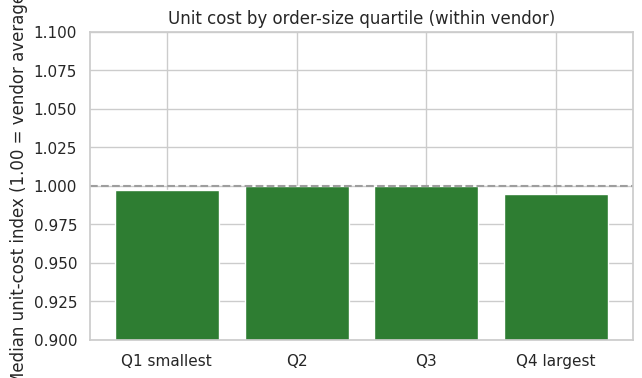

In [7]:
bulk = analysis.bulk_order_effect(purchases); display(bulk)
fig, ax = plt.subplots(figsize=(7, 4)); ax.bar(bulk["OrderSizeQuartile"], bulk["median"], color=GREEN); ax.axhline(1, color=GREY, ls="--")
ax.set_ylim(0.9, 1.1); ax.set_ylabel("Median unit-cost index (1.00 = vendor average)"); ax.set_title("Unit cost by order-size quartile (within vendor)"); plt.show()

Within a vendor, the median unit cost of the largest orders is essentially the same as for the smallest (about 0.3% lower), so **there is no evidence of volume discounts** in this data. Small orders do show a higher *mean* index (1.09 vs 1.00), but that comes from a handful of high-cost invoices, and invoices are not split by SKU, so product mix also moves unit cost. Freight is also about 0.5% of value at every order size, so consolidating orders would not save freight either.

### A6. Research question: how much capital is tied up in inventory?

In [8]:
inv = kf["inventory"]
print(f"Inventory at cost: ${inv['begin_value_at_cost']/1e6:.1f}M (start) -> ${inv['end_value_at_cost']/1e6:.1f}M (end), +{inv['growth_pct']:.1f}%")
u = kf["underperformers"]; print(f"{u['vendors']} Underperformer vendors hold ${u['ending_inventory_at_cost']/1e6:.2f}M of ending inventory at cost on {u['spend_pct']:.1f}% of spend; largest: {', '.join(u['largest_by_inventory'])}")
summary.nlargest(10, "EndValueAtCost")[["VendorName", "BeginValueAtCost", "EndValueAtCost", "InventoryGrowthPct", "StockTurnover", "DaysOfInventory", "Segment"]]

Inventory at cost: $46.9M (start) -> $55.4M (end), +18.2%
23 Underperformer vendors hold $1.86M of ending inventory at cost on 2.4% of spend; largest: STOLI GROUP,(USA) LLC, EDRINGTON AMERICAS, WESTERN SPIRITS BEVERAGE CO


,VendorName,BeginValueAtCost,EndValueAtCost,InventoryGrowthPct,StockTurnover,DaysOfInventory,Segment
0,DIAGEO NORTH AMERICA INC,"6,231,591.37","7,209,768.88",15.70,9.62,38.04,Volume driver - renegotiate cost
1,MARTIGNETTI COMPANIES,"4,959,193.04","5,827,838.15",17.52,5.80,63.09,Star - expand
2,JIM BEAM BRANDS COMPANY,"2,950,037.29","3,802,133.33",28.88,7.56,48.38,Volume driver - renegotiate cost
3,PERNOD RICARD USA,"3,055,229.52","3,608,736.29",18.12,6.80,53.83,Volume driver - renegotiate cost
7,ULTRA BEVERAGE COMPANY LLP,"2,747,051.96","3,464,380.65",26.11,4.84,75.65,Margin builder - tighten stock levels
5,CONSTELLATION BRANDS INC,"2,053,486.81","2,287,842.35",11.41,7.32,49.99,Star - expand
9,M S WALKER INC,"1,764,156.67","2,214,882.81",25.55,5.97,61.30,Star - expand
14,PERFECTA WINES,"1,611,990.86","2,160,511.18",34.03,4.03,90.82,Margin builder - tighten stock levels
4,BACARDI USA INC,"2,302,013.58","2,040,576.53",-11.36,7.15,51.21,Volume driver - renegotiate cost
6,BROWN-FORMAN CORP,"1,608,221.39","1,917,788.73",19.25,7.21,50.78,Volume driver - renegotiate cost


### A7. Hypothesis test: do high-spend and low-spend vendors earn different margins?

H0: mean gross margin is equal for top-quartile and bottom-quartile spend vendors (Welch t-test, vendor level)
top quartile mean 30.93% (n=29) | bottom quartile mean 30.06% (n=29)
difference 0.87 pp | t = 0.607 | p = 0.5464 | 95% CI [-2.01, 3.76] pp
Result: fail to reject H0: no statistically significant difference


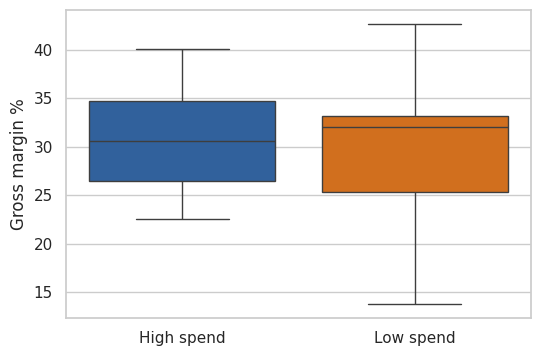

In [9]:
t = kf["margin_hypothesis_test"]
print("H0: mean gross margin is equal for top-quartile and bottom-quartile spend vendors (Welch t-test, vendor level)")
print(f"top quartile mean {t['mean_margin_high_spend']:.2f}% (n={t['n_high_spend']}) | bottom quartile mean {t['mean_margin_low_spend']:.2f}% (n={t['n_low_spend']})")
print(f"difference {t['difference_pp']:.2f} pp | t = {t['t_statistic']:.3f} | p = {t['p_value']:.4f} | 95% CI [{t['ci95_low']:.2f}, {t['ci95_high']:.2f}] pp")
print("Result:", "reject H0" if t["significant_at_5pct"] else "fail to reject H0: no statistically significant difference")
v = el.copy(); hi = v[v["PurchaseDollars"] >= v["PurchaseDollars"].quantile(.75)]; lo = v[v["PurchaseDollars"] <= v["PurchaseDollars"].quantile(.25)]
plt.figure(figsize=(6, 4)); sns.boxplot(data=pd.concat([hi.assign(g="High spend"), lo.assign(g="Low spend")]), x="g", y="GrossMarginPct", palette=[BLUE, ORANGE]); plt.xlabel(""); plt.ylabel("Gross margin %"); plt.show()

Unlike the reference project, there is **no significant margin difference** between high- and low-spend vendors (p about 0.55, and the confidence interval spans zero). Vendor size does not predict profitability here; the segmentation above is more informative than spend alone.

## Part B - Machine-learning model 1: freight cost prediction

**Question:** what freight should an invoice carry, given only what is known when it arrives (order value, quantity, unit cost, lead time, payment terms, calendar, the vendor's typical rate)?

**Design:** temporal hold-out (train before 2024-10-01, test from then on). The model learns *standard* freight, so training excludes the overcharged invoices. A rule-of-thumb baseline (median rate x dollars) is the benchmark, and the simplest ML model within 2% of the best cross-validated MAE is selected.

In [10]:
cand = pd.DataFrame(fm["candidates"]).T[["cv_MAE", "test_MAE", "test_RMSE", "test_R2", "test_MedianAPE_pct", "test_Within10pct"]]
display(cand)
print("Selected ML model:", fm["selected_model"], "|", fm["linear_model_equation"])
print("ML lift vs the 0.5%% rule on test MAE: %+.2f%%  -> ML beats baseline: %s" % (fm["ml_lift_vs_baseline_test_MAE_pct"], fm["ml_beats_baseline"]))
print("Permutation importance (MAE):", {k: v for k, v in fm["permutation_importance_MAE"].items() if v})

,cv_MAE,test_MAE,test_RMSE,test_R2,test_MedianAPE_pct,test_Within10pct
Baseline (median rate x dollars),15.79,17.14,53.68,1.00,5.65,0.91
Linear regression (dollars),15.84,17.15,53.68,1.00,5.63,0.91
"Ridge (dollars, quantity)",15.89,17.52,53.61,1.00,5.08,0.88
Random forest (rate),15.79,17.84,56.74,0.99,5.27,0.90
Gradient boosting (rate),16.41,16.88,49.43,1.00,5.29,0.87


Selected ML model: Linear regression (dollars) | Freight = 0.00500 x Dollars (no intercept)
ML lift vs the 0.5% rule on test MAE: -0.02%  -> ML beats baseline: False
Permutation importance (MAE): {'Dollars': 510.9476}


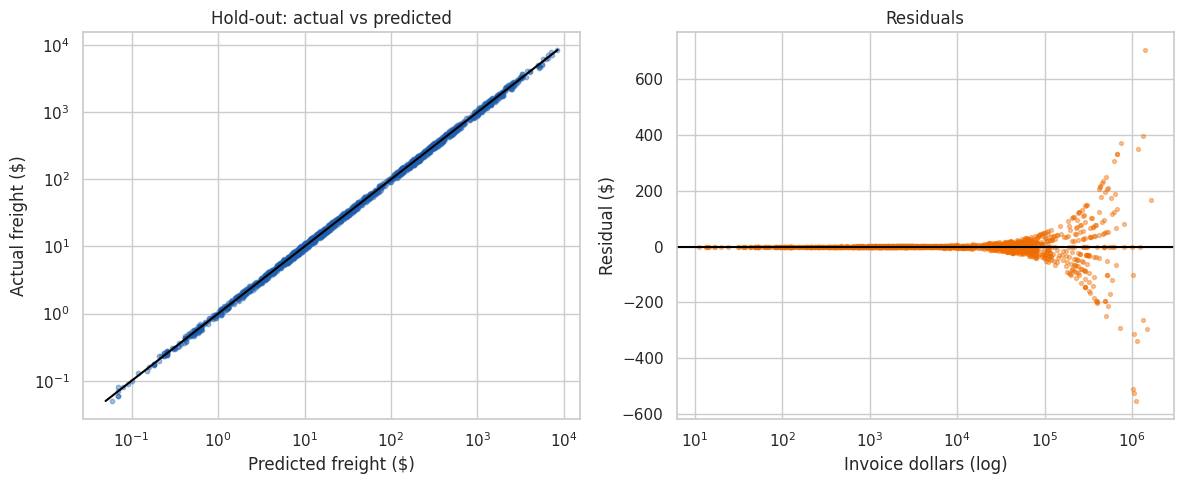

In [11]:
te = risk[risk["InvoiceDate"] >= cfg.TEMPORAL_CUTOFF]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(te["ExpectedFreight"], te["Freight"], s=10, alpha=.4, color=BLUE); lim = [te["Freight"].min(), te["Freight"].max()]
axes[0].plot(lim, lim, color="black"); axes[0].set(xscale="log", yscale="log", xlabel="Predicted freight ($)", ylabel="Actual freight ($)", title="Hold-out: actual vs predicted")
res = (te["Freight"] - te["ExpectedFreight"]); axes[1].scatter(te["Dollars"], res, s=8, alpha=.4, color=ORANGE); axes[1].axhline(0, color="black")
axes[1].set(xscale="log", xlabel="Invoice dollars (log)", ylabel="Residual ($)", title="Residuals"); plt.tight_layout(); plt.show()

**Result:** every model reaches R2 about 0.9955 and a median error of about 5-6%. **No ML model beats the one-line rule "freight = 0.5% of invoice dollars"**, because freight is essentially proportional to order value plus small random variation that none of the other features explain. Complexity does not pay off, so the simplest model (a regression through the origin) is selected, and it is interpretable: freight is 0.5% of invoice value.

The model's real value is as a *benchmark*: invoices whose actual freight is far above the expected amount are overcharges.

In [12]:
fo = fm["freight_model"]["freight_overcharge_summary"] if "freight_model" in fm else fm["freight_overcharge_summary"]
print(json.dumps(fo, indent=1))
r = risk.copy(); r["over"] = r["Flag_FreightAnomaly"] == 1
print("\nTop overcharged invoices by excess $:")
r["Excess"] = r["Freight"] - r["ExpectedFreight"]
r[r["over"]].nlargest(8, "Excess")[["PONumber", "VendorName", "InvoiceDate", "Dollars", "Freight", "ExpectedFreight", "FreightVsExpected", "Excess"]]

{
 "invoices_flagged_freight_anomaly": 86,
 "share_of_all_invoices_pct": 1.55,
 "first_invoice_date": "2024-01-04",
 "last_invoice_date": "2024-01-12",
 "months_affected": [
  "2024-01"
 ],
 "actual_freight_on_flagged_$": 40295.57,
 "expected_freight_on_flagged_$": 7417.9,
 "estimated_excess_freight_$": 32877.67,
 "median_actual_to_expected_ratio": 6.09,
 "share_of_invoices_in_affected_window_pct": 79.6
}

Top overcharged invoices by excess $:


,PONumber,VendorName,InvoiceDate,Dollars,Freight,ExpectedFreight,FreightVsExpected,Excess
69,8173,DIAGEO NORTH AMERICA INC,2024-01-10,"180,644.92","5,972.45",903.34,6.61,"5,069.11"
9,8159,MARTIGNETTI COMPANIES,2024-01-05,"185,155.60","4,613.45",925.89,4.98,"3,687.56"
17,8142,JIM BEAM BRANDS COMPANY,2024-01-06,"151,890.49","3,506.08",759.55,4.62,"2,746.53"
11,8181,PERNOD RICARD USA,2024-01-05,"80,916.64","2,703.94",404.63,6.68,"2,299.31"
93,8106,BACARDI USA INC,2024-01-12,"137,483.78","2,935.20",687.50,4.27,"2,247.70"
58,8150,BROWN-FORMAN CORP,2024-01-09,"65,403.57","1,808.77",327.06,5.53,"1,481.71"
36,8203,ULTRA BEVERAGE COMPANY LLP,2024-01-07,"59,168.69","1,683.03",295.88,5.69,"1,387.15"
72,8108,CONSTELLATION BRANDS INC,2024-01-11,"60,281.13","1,549.81",301.44,5.14,"1,248.37"


The 86 overcharged invoices (all dated 4-12 January 2024) carry a median of about 6 times the expected freight, about **$32.9K of excess freight**, roughly 80% of invoices in that window.

## Part C - Machine-learning model 2: manual-approval (invoice risk) prediction

**Question:** which invoices show misbehaviour and should go to manual approval?

**Target (`ManualApprovalRequired`)** = the $250K approval policy recovered from the data **OR** any anomaly flag:

| Flag | Rule |
|---|---|
| High value | invoice >= $250K |
| Freight overcharge | freight above 1.5x the standard rate |
| Unit-cost outlier | unit cost >= 2x or <= 0.5x the vendor's median |
| Lead-time / payment-terms outlier | |robust z| > 4 versus the vendor's norm |
| Repeat invoice | same vendor, dollars and quantity within 14 days |

The classifier sees only invoice values and how they compare with the vendor's norms (plus the freight model's expected freight), never the flags or the approval column. Vendor norms are computed on training rows only.

> **Honest framing:** the labels are rule-derived (weak supervision), not confirmed fraud. High scores show the policy is learnable and can be scored on new invoices; they do not prove independent fraud detection. For that reason the model is also evaluated on the anomaly-only subset (invoices below $250K) and compared with an unsupervised Isolation Forest.

In [13]:
display(pd.Series(am["label_counts_all_invoices"], name="invoices").to_frame())
print(am["policy_consistency"])

,invoices
Flag_HighValue,374
Flag_FreightAnomaly,86
Flag_UnitCostOutlier,112
Flag_LeadTimeOutlier,8
Flag_PaymentTermsOutlier,2
Flag_PossibleDuplicate,2
ManualApprovalRequired,580
total_invoices,5543


{'historical_approvals': 374, 'approver_names': ['Frank Delahunt'], 'min_approved_dollars': 250689.87, 'max_unapproved_dollars': 249821.96, 'approved_below_threshold': 0, 'high_value_not_approved': 0, 'anomalous_invoices_below_threshold': 206, 'anomalous_below_threshold_never_approved': 206}


In [14]:
cv = pd.DataFrame(am["candidates_cv"]).T; display(cv)
print("Selected:", am["selected_model"], "| decision threshold (max F2 on out-of-fold predictions):", am["decision_threshold"])
tm = am["test_metrics"]; print({k: round(v, 4) for k, v in tm.items() if isinstance(v, float)}); print(tm["confusion"])

,cv_PR_AUC,cv_ROC_AUC
Logistic regression,0.69,0.88
Random forest,1.00,1.00
Gradient boosting,0.99,1.00


Selected: Random forest | decision threshold (max F2 on out-of-fold predictions): 0.2234
{'threshold': 0.2234, 'precision': 0.966, 'recall': 0.9861, 'F1': 0.9759, 'F2': 0.982, 'accuracy': 0.9949, 'ROC_AUC': 0.9974, 'PR_AUC': 0.9935}
{'TN': 1237, 'FP': 5, 'FN': 2, 'TP': 142}


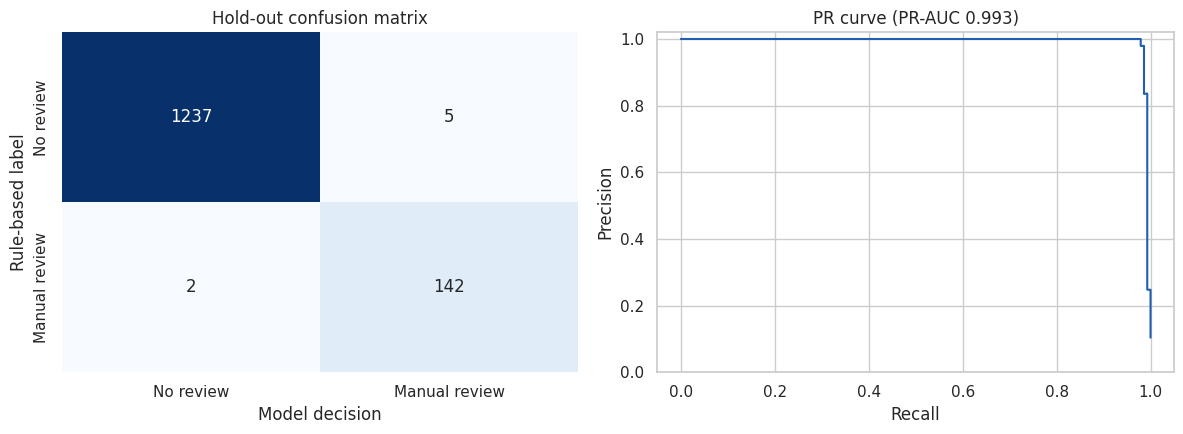

In [15]:
from sklearn.metrics import precision_recall_curve
t = risk[risk["Split"] == "test"]; cm = tm["confusion"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap([[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]], annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0], xticklabels=["No review", "Manual review"], yticklabels=["No review", "Manual review"])
axes[0].set(xlabel="Model decision", ylabel="Rule-based label", title="Hold-out confusion matrix")
p_, r_, _ = precision_recall_curve(t["ManualApprovalRequired"], t["RiskProbability"]); axes[1].plot(r_, p_, color=BLUE)
axes[1].set(xlabel="Recall", ylabel="Precision", title=f"PR curve (PR-AUC {tm['PR_AUC']:.3f})", ylim=(0, 1.02)); plt.tight_layout(); plt.show()

In [16]:
print("Recall by flag on the hold-out set:")
display(pd.DataFrame(am["test_recall_by_flag"]).T)
b = am["test_metrics_invoices_below_250K"]
print("Anomaly-only subset (invoices below $250K): precision %.3f, recall %.3f, PR-AUC %.3f" % (b["precision"], b["recall"], b["PR_AUC"]))
print("Benchmark - the $250K rule alone: precision %.2f, recall %.2f" % (am["benchmark_policy_rule_only_test"]["precision"], am["benchmark_policy_rule_only_test"]["recall"]))
iso = am["isolation_forest_test"]; print("Unsupervised Isolation Forest: ROC-AUC %.3f, PR-AUC %.3f, precision@k %.2f" % (iso["ROC_AUC"], iso["PR_AUC"], iso["precision_at_k"]))
tr = am["temporal_robustness"]; print("Temporal check (train < Oct, test >= Oct): precision %.3f, recall %.3f, PR-AUC %.3f  (%s)" % (tr["precision"], tr["recall"], tr["PR_AUC"], tr["note"]))

Recall by flag on the hold-out set:


,test_invoices,caught,recall
Flag_HighValue,94.00,94.00,1.00
Flag_FreightAnomaly,21.00,21.00,1.00
Flag_UnitCostOutlier,25.00,25.00,1.00
Flag_LeadTimeOutlier,2.00,2.00,1.00
Flag_PaymentTermsOutlier,1.00,0.00,0.00
Flag_PossibleDuplicate,1.00,0.00,0.00


Anomaly-only subset (invoices below $250K): precision 0.906, recall 0.960, PR-AUC 0.974
Benchmark - the $250K rule alone: precision 1.00, recall 0.65
Unsupervised Isolation Forest: ROC-AUC 0.897, PR-AUC 0.485, precision@k 0.47
Temporal check (train < Oct, test >= Oct): precision 0.972, recall 0.983, PR-AUC 0.992  (0 freight anomalies fall in the test period (all occur in January 2024))


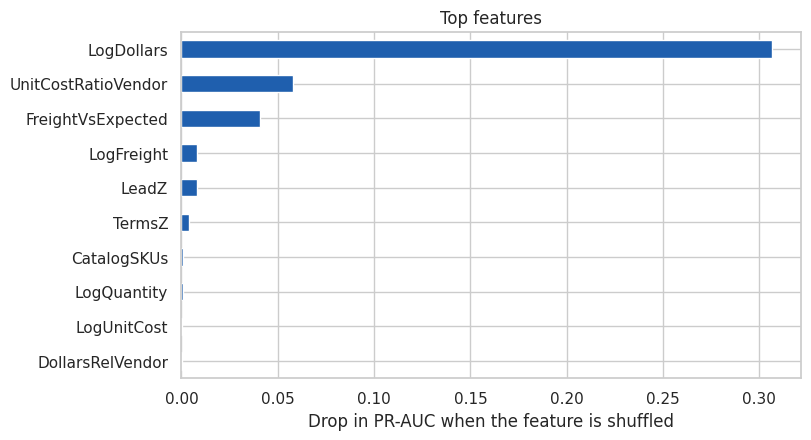

In [17]:
imp = pd.Series(am["permutation_importance_PR_AUC"]).sort_values().tail(10)
plt.figure(figsize=(8, 4.5)); imp.plot.barh(color=BLUE); plt.xlabel("Drop in PR-AUC when the feature is shuffled"); plt.title("Top features"); plt.show()

**Results.** On held-out invoices the model reproduces the review decision with precision about 0.97 and recall about 0.99. The $250K rule on its own catches only about 65% of the invoices that need review; the model adds the unit-cost and freight outliers (about 96% recall on invoices below $250K). It cannot learn the very rare flags (a handful of lead-time, payment-terms and repeat-invoice cases), and the unsupervised Isolation Forest is much weaker (ROC-AUC about 0.90), which confirms the supervised model is doing real work on this task. Invoice value, unit cost versus the vendor norm and freight versus expected freight drive the decisions.

### Control gap: anomalous invoices that were never manually approved

In [18]:
gap = risk[risk["ControlGap"] == 1]
print(f"{len(gap)} invoices below $250K showed at least one anomaly flag but were never manually approved: ${gap['Dollars'].sum()/1e6:.2f}M of purchases")
print(gap["RiskReasons"].str.replace("Freight above 1.5x the standard rate", "Freight overcharge").value_counts())
gap.nlargest(10, "Dollars")[["PONumber", "VendorName", "InvoiceDate", "Dollars", "Freight", "FreightVsExpected", "RiskReasons", "RiskProbability"]]

206 invoices below $250K showed at least one anomaly flag but were never manually approved: $2.58M of purchases
RiskReasons
Unit cost far from vendor norm                        108
Freight overcharge                                     82
Lead time unusual for vendor                            8
Freight overcharge; Unit cost far from vendor norm      4
Payment terms unusual for vendor                        2
Possible duplicate invoice                              2
Name: count, dtype: int64


,PONumber,VendorName,InvoiceDate,Dollars,Freight,FreightVsExpected,RiskReasons,RiskProbability
9,8159,MARTIGNETTI COMPANIES,2024-01-05,"185,155.60","4,613.45",4.98,Freight above 1.5x the standard rate,0.92
69,8173,DIAGEO NORTH AMERICA INC,2024-01-10,"180,644.92","5,972.45",6.61,Freight above 1.5x the standard rate,0.91
17,8142,JIM BEAM BRANDS COMPANY,2024-01-06,"151,890.49","3,506.08",4.62,Freight above 1.5x the standard rate,0.95
93,8106,BACARDI USA INC,2024-01-12,"137,483.78","2,935.20",4.27,Freight above 1.5x the standard rate,0.95
3210,11254,"STOLI GROUP,(USA) LLC",2024-08-09,"121,360.16",546.12,0.90,Unit cost far from vendor norm,0.87
3055,11151,"STOLI GROUP,(USA) LLC",2024-07-29,"97,707.68",498.31,1.02,Unit cost far from vendor norm,0.92
2933,11084,"STOLI GROUP,(USA) LLC",2024-07-20,"88,793.21",479.48,1.08,Unit cost far from vendor norm,0.84
11,8181,PERNOD RICARD USA,2024-01-05,"80,916.64","2,703.94",6.68,Freight above 1.5x the standard rate,0.98
68,8157,M S WALKER INC,2024-01-10,"68,620.75","1,591.50",4.64,Freight above 1.5x the standard rate,0.96
58,8150,BROWN-FORMAN CORP,2024-01-09,"65,403.57","1,808.77",5.53,Freight above 1.5x the standard rate,0.94


### Scoring new invoices

In [19]:
freight_art, approval_art = load_artifacts()
new = pd.DataFrame([
    dict(VendorNumber=3960, InvoiceDate="2024-11-04", Quantity=40000, Dollars=400000, Freight=2000, LeadTimeDays=16, PaymentTermsDays=35, CatalogSKUs=480),
    dict(VendorNumber=4425, InvoiceDate="2024-11-04", Quantity=900, Dollars=9000, Freight=45, LeadTimeDays=15, PaymentTermsDays=34, CatalogSKUs=300),
    dict(VendorNumber=4425, InvoiceDate="2024-11-05", Quantity=900, Dollars=9500, Freight=380, LeadTimeDays=15, PaymentTermsDays=34, CatalogSKUs=300)])
s = score_invoices(new, freight_art, approval_art)
s[["Dollars", "Freight", "ExpectedFreight", "FreightVsExpected", "RiskProbability", "ModelFlagged", "RiskReasons"]]

,Dollars,Freight,ExpectedFreight,FreightVsExpected,RiskProbability,ModelFlagged,RiskReasons
0,400000,2000,"2,000.25",1.00,0.98,1,High-value invoice (>= $250K)
1,9000,45,45.01,1.00,0.01,0,
2,9500,380,47.51,8.00,0.57,1,Freight above 1.5x the standard rate


## Recommendations

1. **Close the approval control gap.** Add anomaly-based triggers (freight above 1.5x expected, unit cost far from the vendor norm) to the $250K rule; 206 anomalous invoices (about $2.6M) never received a manual review.
2. **Investigate and recover the January freight overcharges.** About $33K of excess freight across 86 invoices dated 4-12 January 2024; check whether a surcharge or rate-table error was billed, and monitor freight against the 0.5% expected rate going forward.
3. **Use the scorecard to focus renegotiation.** The *Volume driver* vendors are 56% of spend at below-median margin; a small cost reduction there has the largest profit effect.
4. **Release cash from slow stock.** Inventory at cost grew 18% ($46.9M to $55.4M). Start with the 377 high-margin SKUs whose stock grew and review the 23 *Underperformer* vendors.
5. **Consolidate the vendor tail** (63 vendors supply under 1% of spend) while managing the dependence on the top 10 (65% of spend).
6. **Do not rely on volume-discount assumptions**: median unit cost does not fall with order size, and freight is a flat 0.5%.

## Limitations

- No sales or PO line-item data: units sold, revenue and profit are estimates (inventory balance equation); invoice date stands in for receiving date; lead time is PO-to-invoice (no promised dates, so on-time delivery cannot be measured).
- The approval labels are rule-derived. The model operationalises the policy; it is not independent fraud detection. Rare flags are too infrequent to evaluate.
- Freight overcharges occur in one 9-day window only, so the model cannot be validated on overcharges in later months (the temporal test has none).